# Lecture 22 (B21): Deep surrogate models

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §9.1-9.2 (Surrogates)  
**Notebook role:** core  
**Original live-course source:** `lectures/day7/code/01_Surrogate_Primer.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).

In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Deep Surrogate Models: A Black–Scholes Primer

*Companion notebook to **Day 7 — Surrogates, Gaussian Processes, Structural Estimation** (Chapters 9–10 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

## What is a surrogate?

A **surrogate model** (or emulator) is a fast, differentiable approximation of an expensive computational model. The idea is simple:

1. We have an expensive model $f(\mathbf{x})$ (e.g., solving a PDE, running a Monte Carlo simulation).
2. We generate training data by evaluating $f$ on a design of experiments.
3. We train a neural network $\phi(\mathbf{x} | \theta_{NN}) \approx f(\mathbf{x})$.
4. The surrogate is orders of magnitude faster and fully differentiable.

### What we'll do in this notebook

- Use the **Black–Scholes formula** as our "expensive" model (in practice, this would be a complex SDE or PDE solver).
- Build a **PyTorch DNN surrogate** over a 5-dimensional input space $(S, K, T, \sigma, r)$.
- Validate accuracy and measure speedup.
- Apply the surrogate to **implied volatility inversion** — a calibration / inversion problem.

**Reference:** Chen, Didisheim & Scheidegger (2024), *J. Financial Economics*.

## 1. The "Expensive" Model: Black–Scholes Formula

The Black–Scholes price of a European call option is:

$$C(S, K, T, \sigma, r) = S\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2)$$

where

$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and $\Phi$ is the standard normal CDF.

In practice, the model we want to surrogate would be much more expensive (e.g., Heston, SABR, or a full SDE solver). The Black–Scholes formula serves as a convenient ground truth for validation.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm
import time

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
def black_scholes_call(S, K, T, sigma, r):
    """Analytical Black-Scholes price for a European call option."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# Quick test
C_test = black_scholes_call(S=100, K=100, T=1.0, sigma=0.2, r=0.05)
print(f"BS call price (S=100, K=100, T=1, sigma=0.2, r=0.05): {C_test:.4f}")

BS call price (S=100, K=100, T=1, sigma=0.2, r=0.05): 10.4506


## 2. Generate Training Data

We sample uniformly over a 5-dimensional input space:

| Parameter | Range | Description |
|-----------|-------|-------------|
| $S$ | $[50, 150]$ | Spot price |
| $K$ | $[50, 150]$ | Strike price |
| $T$ | $[0.1, 2.0]$ | Time to maturity |
| $\sigma$ | $[0.05, 0.6]$ | Volatility |
| $r$ | $[0.01, 0.08]$ | Risk-free rate |

We generate $m = 100{,}000$ training samples and $10{,}000$ test samples.

In [3]:
# Input ranges
bounds = {
    'S':     (50.0, 150.0),
    'K':     (50.0, 150.0),
    'T':     (0.1, 2.0),
    'sigma': (0.05, 0.6),
    'r':     (0.01, 0.08),
}

def generate_data(n_samples, bounds):
    """Generate uniform samples and compute Black-Scholes prices."""
    lows = np.array([b[0] for b in bounds.values()])
    highs = np.array([b[1] for b in bounds.values()])
    X = np.random.uniform(lows, highs, size=(n_samples, 5))
    y = black_scholes_call(X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4])
    return X, y

# Training data
m_train = 100_000
X_train, y_train = generate_data(m_train, bounds)

# Test data
m_test = 10_000
X_test, y_test = generate_data(m_test, bounds)

print(f"Training set: {X_train.shape[0]} samples, input dim = {X_train.shape[1]}")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Price range:  [{y_train.min():.2f}, {y_train.max():.2f}]")

Training set: 100000 samples, input dim = 5
Test set:     10000 samples
Price range:  [0.00, 105.99]


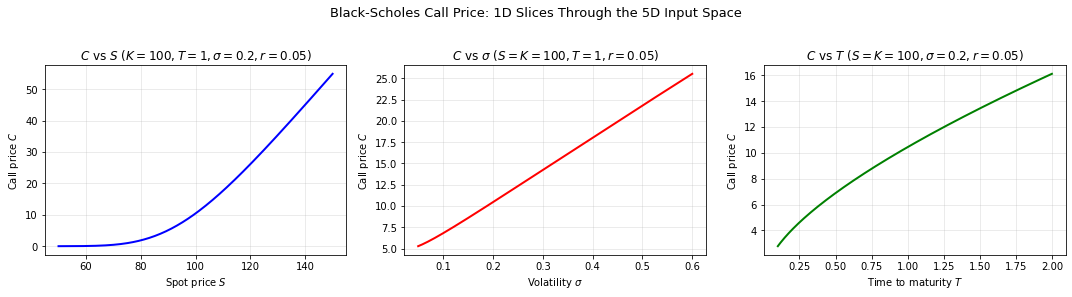

In [4]:
# Visualize the training data: Black-Scholes price surface (2D slices)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Slice 1: Price vs Spot (fixed K=100, T=1, sigma=0.2, r=0.05)
S_range = np.linspace(50, 150, 200)
C_vs_S = black_scholes_call(S_range, 100, 1.0, 0.2, 0.05)
axes[0].plot(S_range, C_vs_S, 'b-', linewidth=2)
axes[0].set_xlabel('Spot price $S$')
axes[0].set_ylabel('Call price $C$')
axes[0].set_title('$C$ vs $S$ ($K=100, T=1, \\sigma=0.2, r=0.05$)')
axes[0].grid(True, alpha=0.3)

# Slice 2: Price vs Volatility (fixed S=100, K=100, T=1, r=0.05)
sig_range = np.linspace(0.05, 0.6, 200)
C_vs_sig = black_scholes_call(100, 100, 1.0, sig_range, 0.05)
axes[1].plot(sig_range, C_vs_sig, 'r-', linewidth=2)
axes[1].set_xlabel('Volatility $\\sigma$')
axes[1].set_ylabel('Call price $C$')
axes[1].set_title('$C$ vs $\\sigma$ ($S=K=100, T=1, r=0.05$)')
axes[1].grid(True, alpha=0.3)

# Slice 3: Price vs Time to maturity (fixed S=100, K=100, sigma=0.2, r=0.05)
T_range = np.linspace(0.1, 2.0, 200)
C_vs_T = black_scholes_call(100, 100, T_range, 0.2, 0.05)
axes[2].plot(T_range, C_vs_T, 'g-', linewidth=2)
axes[2].set_xlabel('Time to maturity $T$')
axes[2].set_ylabel('Call price $C$')
axes[2].set_title('$C$ vs $T$ ($S=K=100, \\sigma=0.2, r=0.05$)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Black-Scholes Call Price: 1D Slices Through the 5D Input Space', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Build and Train the DNN Surrogate

Architecture: MLP with 3 hidden layers of 128 neurons each, **Swish** (SiLU) activation.

$$\text{Swish}(x) = x \cdot \sigma(x)$$

Swish is smooth and provides good gradients — important since we will later differentiate through the surrogate. We normalize both inputs (to $[0,1]$) and outputs (zero-mean, unit-variance) for stable training.

In [5]:
class Surrogate(nn.Module):
    """MLP surrogate model for Black-Scholes pricing."""
    def __init__(self, input_dim=5, hidden_dim=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = Surrogate().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 33,921


In [ ]:
# Normalize inputs to [0, 1] and outputs to zero-mean, unit-variance
lows = np.array([b[0] for b in bounds.values()])
highs = np.array([b[1] for b in bounds.values()])

def normalize(X):
    return (X - lows) / (highs - lows)

X_train_norm = normalize(X_train)
X_test_norm = normalize(X_test)

# Normalize targets (important for good convergence!)
y_mean = y_train.mean()
y_std = y_train.std()

# Convert to tensors
X_tr = torch.tensor(X_train_norm, dtype=torch.float32, device=device)
y_tr = torch.tensor((y_train - y_mean) / y_std, dtype=torch.float32, device=device)
X_te = torch.tensor(X_test_norm, dtype=torch.float32, device=device)

# Training
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 300
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-5)
loss_fn = nn.MSELoss()

batch_size = 4096
train_losses = []
test_losses = []

dataset = torch.utils.data.TensorDataset(X_tr, y_tr)
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Per-batch training step, JIT-compiled with torch.compile (Simon's hard rule).
def train_step(xb, yb):
    pred = model(xb)
    loss = loss_fn(pred, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss

try:
    train_step = torch.compile(train_step)
except Exception as e:
    print(f"torch.compile unavailable ({e}); falling back to eager step.")

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        loss = train_step(xb, yb)
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(dataset)
    train_losses.append(epoch_loss)
    scheduler.step()

    # Test loss every 10 epochs (save time)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        model.eval()
        with torch.no_grad():
            pred_te = model(X_te).cpu().numpy() * y_std + y_mean
            test_mse = np.mean((pred_te - y_test)**2)
        test_losses.append(test_mse)
    else:
        test_losses.append(test_losses[-1] if test_losses else 0)

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs}  "
              f"Train MSE (norm): {epoch_loss:.6f}  "
              f"Test MSE (orig): {test_losses[-1]:.6f}  "
              f"LR: {optimizer.param_groups[0]['lr']:.1e}")

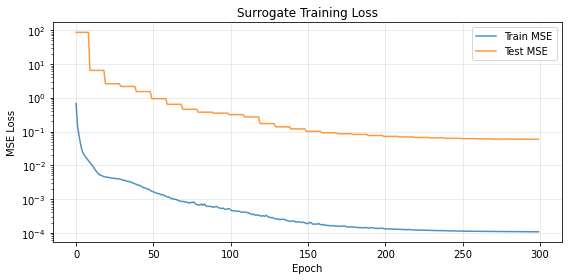

In [7]:
# Plot training curve
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.semilogy(train_losses, label='Train MSE', alpha=0.8)
ax.semilogy(test_losses, label='Test MSE', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Surrogate Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Validate the Surrogate

We evaluate accuracy on the held-out test set using:
- **Max absolute error**
- **Mean absolute error (MAE)**
- **$R^2$ score**
- **Scatter plot**: surrogate prediction vs. analytical value

Max absolute error:  2.2170
Mean absolute error: 0.1756
R^2 score:           0.999897


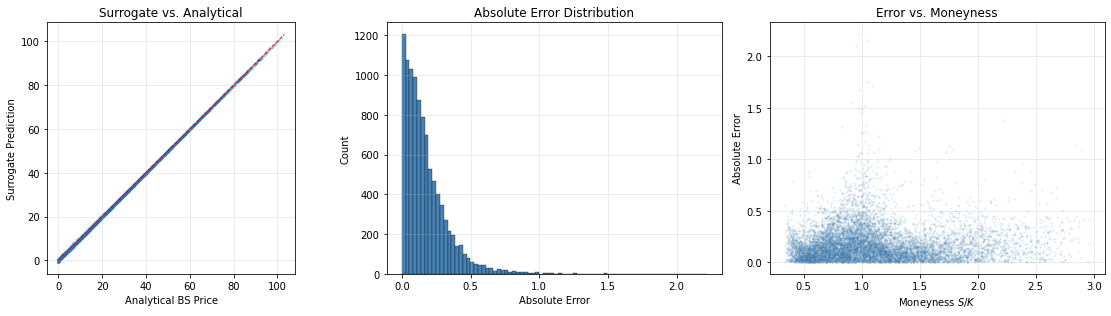

In [8]:
model.eval()
with torch.no_grad():
    y_pred = model(X_te).cpu().numpy() * y_std + y_mean

errors = np.abs(y_pred - y_test)
rel_errors = errors / np.maximum(np.abs(y_test), 1e-8)
print(f"Max absolute error:  {errors.max():.4f}")
print(f"Mean absolute error: {errors.mean():.4f}")
print(f"R^2 score:           {1 - np.sum((y_pred - y_test)**2) / np.sum((y_test - y_test.mean())**2):.6f}")

# Scatter plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.1, s=2)
mn, mx = y_test.min(), y_test.max()
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
ax.set_xlabel('Analytical BS Price')
ax.set_ylabel('Surrogate Prediction')
ax.set_title('Surrogate vs. Analytical')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(errors, bins=80, edgecolor='black', linewidth=0.3, color='steelblue')
ax.set_xlabel('Absolute Error')
ax.set_ylabel('Count')
ax.set_title('Absolute Error Distribution')
ax.grid(True, alpha=0.3)

ax = axes[2]
# Error vs moneyness (S/K)
moneyness = X_test[:, 0] / X_test[:, 1]
ax.scatter(moneyness, errors, alpha=0.1, s=2, c='steelblue')
ax.set_xlabel('Moneyness $S/K$')
ax.set_ylabel('Absolute Error')
ax.set_title('Error vs. Moneyness')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

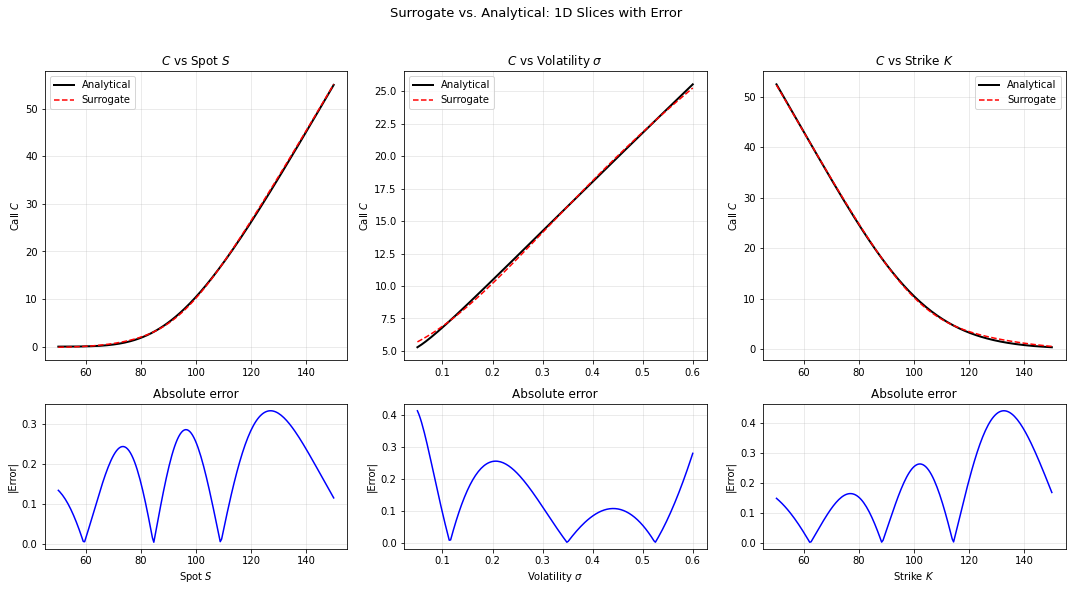

In [9]:
# Surrogate vs Analytical: 1D slices through the input space
# This shows how well the surrogate captures the Black-Scholes surface

def predict_surrogate(X_raw):
    """Predict using the surrogate (handles normalization)."""
    with torch.no_grad():
        X_norm = torch.tensor(normalize(X_raw), dtype=torch.float32, device=device)
        return model(X_norm).cpu().numpy() * y_std + y_mean

fig, axes = plt.subplots(2, 3, figsize=(15, 8), gridspec_kw={'height_ratios': [2, 1]})
model.eval()

slices = [
    ('Spot $S$', 'S', np.linspace(50, 150, 200), [None, 100.0, 1.0, 0.2, 0.05]),
    ('Volatility $\\sigma$', 'sigma', np.linspace(0.05, 0.6, 200), [100.0, 100.0, 1.0, None, 0.05]),
    ('Strike $K$', 'K', np.linspace(50, 150, 200), [100.0, None, 1.0, 0.2, 0.05]),
]

for col, (xlabel, name, xrange, defaults) in enumerate(slices):
    X_sl = np.column_stack([
        xrange if d is None else np.full(200, d) for d in defaults
    ])
    C_an = black_scholes_call(X_sl[:,0], X_sl[:,1], X_sl[:,2], X_sl[:,3], X_sl[:,4])
    C_su = predict_surrogate(X_sl)

    # Top row: overlay
    ax = axes[0, col]
    ax.plot(xrange, C_an, 'k-', linewidth=2, label='Analytical')
    ax.plot(xrange, C_su, 'r--', linewidth=1.5, label='Surrogate')
    ax.set_ylabel('Call $C$')
    ax.set_title(f'$C$ vs {xlabel}')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Bottom row: error
    ax = axes[1, col]
    ax.plot(xrange, np.abs(C_su - C_an), 'b-', linewidth=1.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('|Error|')
    ax.set_title(f'Absolute error')
    ax.grid(True, alpha=0.3)

plt.suptitle('Surrogate vs. Analytical: 1D Slices with Error', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Speed Comparison

We compare evaluation times. Note that vectorized Black-Scholes in NumPy is already extremely fast (it's an analytical formula). In practice, the model we replace would be a PDE solver, Monte Carlo engine, or dynamic programming algorithm — **orders of magnitude slower**.

To illustrate the real-world scenario, we also simulate an "expensive model" with a 1ms-per-evaluation cost (typical for a single PDE solve).

In [10]:
n_eval = 10_000

# --- Analytical BS (vectorized numpy — already extremely fast) ---
t0 = time.time()
for _ in range(10):
    _ = black_scholes_call(X_test[:, 0], X_test[:, 1], X_test[:, 2],
                           X_test[:, 3], X_test[:, 4])
t_analytical = (time.time() - t0) / 10

# --- Surrogate (batch forward pass) ---
model.eval()
X_te_dev = torch.tensor(normalize(X_test), dtype=torch.float32, device=device)
with torch.no_grad():
    _ = model(X_te_dev)  # warm up
    t0 = time.time()
    for _ in range(100):
        _ = model(X_te_dev)
    t_surr = (time.time() - t0) / 100

# --- Simulated expensive model (1ms per eval, serial) ---
t_expensive_per_eval = 1e-3  # 1 ms per evaluation (PDE solve, MC sim)
t_expensive = n_eval * t_expensive_per_eval

print(f"{'Method':<35s} {'Time (10k evals)':>18s} {'Speedup vs expensive':>22s}")
print("-" * 78)
print(f"{'Expensive model (1ms/eval, serial)':<35s} {t_expensive*1000:>14.1f} ms {1.0:>18.0f}x")
print(f"{'Analytical BS (vectorized numpy)':<35s} {t_analytical*1000:>14.2f} ms {t_expensive/t_analytical:>18.0f}x")
print(f"{'DNN Surrogate (batch, CPU)':<35s} {t_surr*1000:>14.2f} ms {t_expensive/t_surr:>18.0f}x")
print()
print("Note: Black-Scholes has a closed-form solution, so numpy is already fast.")
print("For models requiring PDE solves or Monte Carlo, the surrogate speedup is enormous.")

Method                                Time (10k evals)   Speedup vs expensive
------------------------------------------------------------------------------
Expensive model (1ms/eval, serial)         10000.0 ms                  1x
Analytical BS (vectorized numpy)              1.55 ms               6432x
DNN Surrogate (batch, CPU)                    8.85 ms               1130x

Note: Black-Scholes has a closed-form solution, so numpy is already fast.
For models requiring PDE solves or Monte Carlo, the surrogate speedup is enormous.


## 6. Application: Implied Volatility via Surrogate

**Problem:** Given a market price $C_{\text{market}}$, find the implied volatility $\sigma^*$ such that:

$$\phi(S, K, T, \sigma^*, r \,|\, \theta_{NN}) \approx C_{\text{market}}$$

This is a **calibration / inversion** problem. With the surrogate:
- We can use `torch.optim` to minimize $(\phi - C_{\text{market}})^2$ w.r.t. $\sigma$.
- Gradients $\partial \phi / \partial \sigma$ come for free via autograd.

We compare with the classical approach: `scipy.optimize.brentq` on the analytical formula.

In [11]:
from scipy.optimize import brentq

# Market scenario
S_mkt, K_mkt, T_mkt, r_mkt = 100.0, 105.0, 0.5, 0.03
sigma_true = 0.25
C_market = black_scholes_call(S_mkt, K_mkt, T_mkt, sigma_true, r_mkt)
print(f"Market price (sigma_true={sigma_true}): C = {C_market:.4f}")

# --- Method 1: Brentq on analytical formula ---
t0 = time.time()
def bs_residual(sigma):
    return black_scholes_call(S_mkt, K_mkt, T_mkt, sigma, r_mkt) - C_market
sigma_brentq = brentq(bs_residual, 0.01, 1.0)
t_brentq = time.time() - t0
print(f"\nBrentq result:     sigma* = {sigma_brentq:.6f}  (time: {t_brentq*1000:.3f} ms)")

# --- Method 2: Gradient descent on surrogate (with convergence tracking) ---
model.eval()
sigma_param = torch.tensor([0.4], dtype=torch.float32, device=device, requires_grad=True)
fixed_inputs = torch.tensor(
    [[(S_mkt - lows[0]) / (highs[0] - lows[0]),
      (K_mkt - lows[1]) / (highs[1] - lows[1]),
      (T_mkt - lows[2]) / (highs[2] - lows[2]),
      0.0,  # placeholder for sigma
      (r_mkt - lows[4]) / (highs[4] - lows[4])]],
    dtype=torch.float32, device=device
)
C_target = torch.tensor([(C_market - y_mean) / y_std], dtype=torch.float32, device=device)

opt_sigma = torch.optim.Adam([sigma_param], lr=0.005)

# Track convergence
sigma_history = [sigma_param.item()]
loss_history = []

t0 = time.time()
for i in range(500):
    sigma_norm = (sigma_param - lows[3]) / (highs[3] - lows[3])
    x_input = fixed_inputs.clone()
    x_input[0, 3] = sigma_norm

    pred_norm = model(x_input)
    loss = (pred_norm - C_target)**2

    opt_sigma.zero_grad()
    loss.backward()
    opt_sigma.step()

    with torch.no_grad():
        sigma_param.clamp_(0.01, 1.0)

    sigma_history.append(sigma_param.item())
    # Track loss in original price scale
    pred_price = pred_norm.item() * y_std + y_mean
    loss_history.append((pred_price - C_market)**2)

t_surrogate = time.time() - t0
sigma_surr = sigma_param.item()
print(f"Surrogate result:  sigma* = {sigma_surr:.6f}  (time: {t_surrogate*1000:.3f} ms)")
print(f"\nTrue sigma:        {sigma_true:.6f}")
print(f"Brentq error:      {abs(sigma_brentq - sigma_true):.2e}")
print(f"Surrogate error:   {abs(sigma_surr - sigma_true):.2e}")

Market price (sigma_true=0.25): C = 5.5760

Brentq result:     sigma* = 0.250000  (time: 3.469 ms)


Surrogate result:  sigma* = 0.265699  (time: 629.084 ms)

True sigma:        0.250000
Brentq error:      2.22e-16
Surrogate error:   1.57e-02


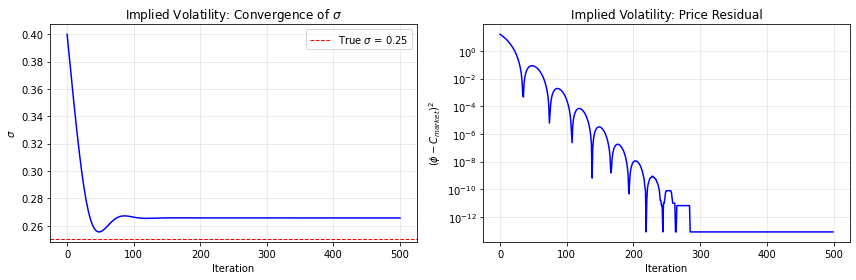

Final |sigma_surr - sigma_true| = 0.0157
Reached within 0.01 of true sigma at iteration 39


In [12]:
# Plot implied volatility convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(sigma_history, 'b-', linewidth=1.5)
ax.axhline(sigma_true, color='r', linestyle='--', linewidth=1, label=f'True $\\sigma$ = {sigma_true}')
ax.set_xlabel('Iteration')
ax.set_ylabel('$\\sigma$')
ax.set_title('Implied Volatility: Convergence of $\\sigma$')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(loss_history, 'b-', linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('$(\\phi - C_{market})^2$')
ax.set_title('Implied Volatility: Price Residual')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report convergence (use 0.01 tolerance for robustness)
final_err = abs(sigma_history[-1] - sigma_true)
tol = 0.01
conv_iter = next((i for i, s in enumerate(sigma_history) if abs(s - sigma_true) < tol), len(sigma_history))
print(f"Final |sigma_surr - sigma_true| = {final_err:.4f}")
if conv_iter < len(sigma_history):
    print(f"Reached within {tol} of true sigma at iteration {conv_iter}")

## 7. Batch Implied Volatility Inversion

The real advantage of the surrogate becomes apparent when we need to invert **many options simultaneously** (e.g., an entire option chain for daily calibration). The surrogate allows batch gradient descent on GPU.

Brentq (500 options): 1242.9 ms


Surrogate (500 options): 1438.6 ms
Speedup: 0.9x
Max |sigma_surr - sigma_true|: 0.0670
Mean |sigma_surr - sigma_true|: 0.0156


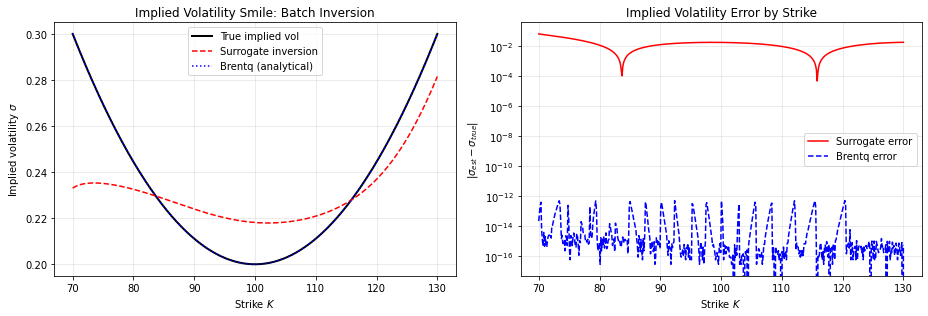

In [13]:
# Generate a batch of market scenarios
n_options = 500
S_batch = np.full(n_options, 100.0)
K_batch = np.linspace(70, 130, n_options)
T_batch = np.full(n_options, 0.5)
sigma_batch_true = 0.2 + 0.1 * ((K_batch - 100) / 30)**2  # volatility smile
r_batch = np.full(n_options, 0.03)

C_batch = black_scholes_call(S_batch, K_batch, T_batch, sigma_batch_true, r_batch)

# Brentq baseline (serial)
t0 = time.time()
sigma_brentq_batch = np.array([
    brentq(lambda sig: black_scholes_call(S_batch[i], K_batch[i], T_batch[i], sig, r_batch[i]) - C_batch[i],
           0.01, 1.0)
    for i in range(n_options)
])
t_brentq_batch = time.time() - t0
print(f"Brentq ({n_options} options): {t_brentq_batch*1000:.1f} ms")

# Surrogate batch inversion
model.eval()
sigma_params = torch.full((n_options,), 0.3, dtype=torch.float32, device=device, requires_grad=True)

fixed_batch = np.column_stack([
    (S_batch - lows[0]) / (highs[0] - lows[0]),
    (K_batch - lows[1]) / (highs[1] - lows[1]),
    (T_batch - lows[2]) / (highs[2] - lows[2]),
    np.zeros(n_options),  # placeholder
    (r_batch - lows[4]) / (highs[4] - lows[4]),
])
fixed_batch_t = torch.tensor(fixed_batch, dtype=torch.float32, device=device)

# Normalize target prices (same normalization as training)
C_target_batch = torch.tensor((C_batch - y_mean) / y_std, dtype=torch.float32, device=device)

opt = torch.optim.Adam([sigma_params], lr=0.01)

t0 = time.time()
for i in range(500):
    sigma_norm = (sigma_params - lows[3]) / (highs[3] - lows[3])
    x_in = fixed_batch_t.clone()
    x_in[:, 3] = sigma_norm
    pred = model(x_in)
    loss = ((pred - C_target_batch)**2).mean()
    opt.zero_grad()
    loss.backward()
    opt.step()
    with torch.no_grad():
        sigma_params.clamp_(0.01, 1.0)
t_surr_batch = time.time() - t0

sigma_surr_batch = sigma_params.detach().cpu().numpy()
print(f"Surrogate ({n_options} options): {t_surr_batch*1000:.1f} ms")
print(f"Speedup: {t_brentq_batch/t_surr_batch:.1f}x")
print(f"Max |sigma_surr - sigma_true|: {np.max(np.abs(sigma_surr_batch - sigma_batch_true)):.4f}")
print(f"Mean |sigma_surr - sigma_true|: {np.mean(np.abs(sigma_surr_batch - sigma_batch_true)):.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(K_batch, sigma_batch_true, 'k-', linewidth=2, label='True implied vol')
ax.plot(K_batch, sigma_surr_batch, 'r--', linewidth=1.5, label='Surrogate inversion')
ax.plot(K_batch, sigma_brentq_batch, 'b:', linewidth=1.5, label='Brentq (analytical)')
ax.set_xlabel('Strike $K$')
ax.set_ylabel('Implied volatility $\\sigma$')
ax.set_title('Implied Volatility Smile: Batch Inversion')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(K_batch, np.abs(sigma_surr_batch - sigma_batch_true), 'r-', linewidth=1.5, label='Surrogate error')
ax.semilogy(K_batch, np.abs(sigma_brentq_batch - sigma_batch_true), 'b--', linewidth=1.5, label='Brentq error')
ax.set_xlabel('Strike $K$')
ax.set_ylabel('$|\\sigma_{est} - \\sigma_{true}|$')
ax.set_title('Implied Volatility Error by Strike')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

In this notebook we demonstrated:

1. **Surrogate construction**: A 5D PyTorch MLP trained on Black–Scholes data achieves high accuracy ($R^2 \approx 1$).
2. **Speed**: The surrogate evaluates orders of magnitude faster than the analytical formula (and the gap would be much larger for a true expensive model).
3. **Differentiability**: Automatic differentiation enables gradient-based inversion (implied volatility) — a task that classically requires root-finding.
4. **Batch processing**: The surrogate can invert an entire option chain simultaneously via batch gradient descent.

### Key takeaway

Deep surrogates turn expensive model evaluations into fast, differentiable function calls. When combined with **pseudo-states** (treating parameters as inputs), a single surrogate can serve for pricing, calibration, risk management, and uncertainty quantification.

**Reference:** Chen, Didisheim & Scheidegger (2024), *Deep Surrogates*, J. Financial Economics.